With this model, im aiming for interpretability - to understand *what* drives purchasing in a given session. Therefore I'll be building a logistic regression model, in order to see the biggest contributors to purchase outcomes.

In [69]:
# The robust scaler is the best choice for handling the extreme outliers in the duration columns.

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv('../data/clean_online_shoppers_dataset.csv')

X = df.drop(columns=['Revenue'])
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True))
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True))

Train shape: (9859, 32) (9859,)
Test shape: (2465, 32) (2465,)

Class distribution (train):
Revenue
False    0.845218
True     0.154782
Name: proportion, dtype: float64

Class distribution (test):
Revenue
False    0.84503
True     0.15497
Name: proportion, dtype: float64


In [72]:
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2 and set(X_train[col].unique()).issubset({0,1})]

continuous_cols = [col for col in X_train.columns if col not in binary_cols]

print("Binary columns:", binary_cols)
print("Continuous columns:", continuous_cols)

Binary columns: ['TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_20', 'TrafficType_Other', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'is_special_day', 'Visited_Informational', 'has_bounce', 'high_exit_rate']
Continuous columns: ['Administrative', 'Informational', 'ProductRelated', 'ExitRates', 'Administrative_Duration_log', 'PageValues_log', 'ProductRelated_Duration_sqrt']


In [73]:
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(X_train_scaled[continuous_cols].describe())
print("\nBinary cols untouched, sample:")
print(X_train_scaled[binary_cols].head())

       Administrative  Informational  ProductRelated    ExitRates  \
count     9859.000000    9859.000000     9859.000000  9859.000000   
mean         0.330510       0.505427        0.444228     0.500072   
std          0.833041       1.256691        1.409018     1.353127   
min         -0.250000       0.000000       -0.580645    -0.700000   
25%         -0.250000       0.000000       -0.354839    -0.300000   
50%          0.000000       0.000000        0.000000     0.000000   
75%          0.750000       0.000000        0.645161     0.700000   
max          6.500000      16.000000       18.258065     4.900000   

       Administrative_Duration_log  PageValues_log  \
count                  9859.000000     9859.000000   
mean                      0.047861        0.624058   
std                       0.520461        1.267545   
min                      -0.459295        0.000000   
25%                      -0.459295        0.000000   
50%                       0.000000        0.000000   


## Unsupervised Modeling - K-Means Clusters

In [74]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled[continuous_cols])
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled[continuous_cols], labels))

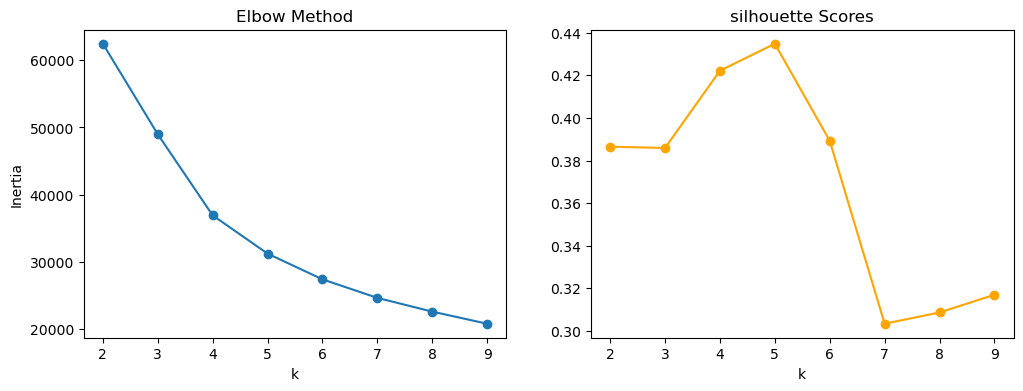

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertias, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(K_range, silhouette_scores, marker='o', color='orange')
ax[1].set_title("silhouette Scores")
ax[1].set_xlabel("k")
plt.show()

The elbow is at k=4, after which inertia decreases at a smaller rate.
Although the silhouette score peak is at k=5, k=4 is a close second, and only ~1.5 points less.
Based off of these metrics, centroids set at 4 will provide the most meaningful groups.

In [76]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled[continuous_cols])

X_train_clustered = X_train_scaled[continuous_cols].copy()
X_train_clustered['Cluster'] = cluster_labels

print(X_train_clustered['Cluster'].value_counts().sort_index())

Cluster
0    1651
1    1171
2     880
3    6157
Name: count, dtype: int64


In [77]:
cluster_profile = X_train_clustered.groupby('Cluster').mean()
print(cluster_profile)

         Administrative  Informational  ProductRelated  ExitRates  \
Cluster                                                             
0              0.635070       0.516657        0.535687  -0.157264   
1             -0.233134       0.017933       -0.473568   3.701941   
2              1.429545       2.898864        3.521334  -0.150807   
3              0.198961       0.253045        0.154458   0.160402   

         Administrative_Duration_log  PageValues_log  \
Cluster                                                
0                           0.312297        3.134114   
1                          -0.439231        0.000000   
2                           0.534421        1.021323   
3                           0.000051        0.012895   

         ProductRelated_Duration_sqrt  
Cluster                                
0                            0.408069  
1                           -0.784340  
2                            1.652264  
3                            0.026128  


Looking at the tables alone, the 4 clusters show distinct patterns.

Cluster 1 shows the lowest number of pages visited for each type, with higher than typical exit rates, average page values, and less time spent on both administrative and product pages.

Cluster 2 shows the opposite of that- a higher number of page visits for all types, lower exit rates, longer page visit durations, and higher page values.

The two other clusters sit with values in between the other 2 clusters, sharing the same pattern but to a lesser magnitude.

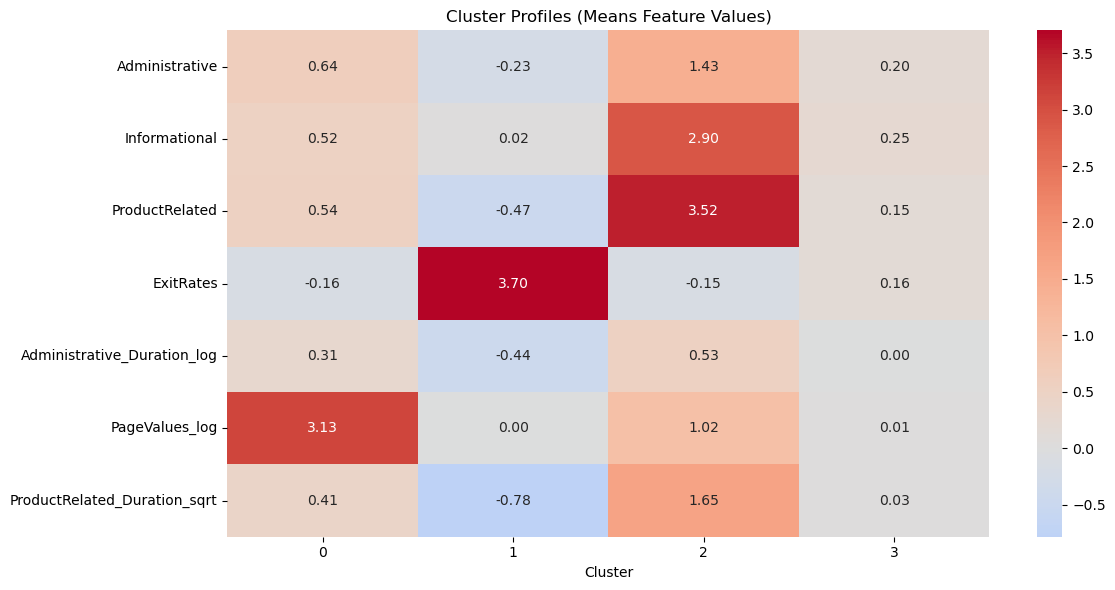

In [78]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.T, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title("Cluster Profiles (Means Feature Values)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

In [79]:
X_train_clustered['Revenue'] = y_train.values

revenue_by_cluster = X_train_clustered.groupby('Cluster')['Revenue'].mean()
print("\nPurchase rate (Revenue=True) by cluster:")
print(revenue_by_cluster.sort_values(ascending=False))


Purchase rate (Revenue=True) by cluster:
Cluster
0    0.612962
2    0.275000
3    0.042878
1    0.006832
Name: Revenue, dtype: float64


In [80]:
print(X_train_clustered['Cluster'].value_counts().sort_index())

Cluster
0    1651
1    1171
2     880
3    6157
Name: count, dtype: int64


The highest revenue generating cluster is cluster 0, with 61% of sessions making a purchase. They consist of exceptionally higher PageValues, and higher page durations and page visits, as well as lower exit rates. This cluster makes up 17% of the sessions.

The second highest revenue cluster is cluster 2, with ~28% of sessions ending in a purchase. These sessions consist of noticeably higher page visit numbers (especially for product related pages), visit durations, higher page values, and lower exit rates, indicative of an active shopper exploring their options, and converting at a moderate rate- half that of cluster 0. Cluster 2 made up ~9% of sessions in the training data.

Cluster 3 had the third largest purchase rate, however, only 4% of sessions ended with a purchase. Features showed typical values, with the number of page visits slightly elevated, indicating casual browsing, short sessions, and a small conversion rate. This cluster made up 62% of all sessions in the training data.

Cluster 1 showed the smallest purchase rate, with only 0.68% of sessions ending in a purchase. This cluster showed a very high exit rate, and comparatively lower page visits and visit durations than all other clusters.